In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
print("Loaded Succesfully")

Loaded Succesfully


In [10]:
infrastructure = pd.read_csv(r"C:\Users\Mahadeva\OneDrive\Desktop\AI City intelligence\data\raw\eb1fa0a4-e095-476b-af46-382094ddda53.csv")
print("loaded succesfully")
operations = pd.read_csv(r"C:\Users\Mahadeva\OneDrive\Desktop\AI City intelligence\data\raw\e333a07c-9d92-4b9a-a856-9eb29055f772.csv")
print("loaded succesfully")
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

loaded succesfully
loaded succesfully


In [7]:
print(infrastructure.shape)
print(operations.shape)

(125, 7)
(74, 6)


In [11]:
infrastructure.columns = [
    "city",
    "bus_type",
    "bus_count",
    "bus_terminals",
    "bus_stands",
    "bus_stops"
]

operations.columns = [
    "city",
    "year",
    "daily_trips",
    "daily_passengers",
    "daily_trip_length_km",
    "daily_cost_rupees",
    "revenue_per_km"
]

infrastructure.head(), operations.head()

(        city bus_type bus_count  bus_terminals  bus_stands  bus_stops
 0   Agartala       AC        11            3.0         6.0       48.0
 1   Agartala   Non AC       162            3.0         6.0       48.0
 2       Agra   Non AC       170           20.0         5.0       30.0
 3  Ahmedabad       AC       189           16.0      1157.0     1157.0
 4  Ahmedabad   Non AC       751           16.0      1157.0     1157.0,
      city     year  daily_trips  daily_passengers  daily_trip_length_km  \
 0    Agra  2015-16        245.0           20222.0               16546.0   
 1    Agra  2016-17        258.0           16392.0               15030.0   
 2    Agra  2017-18        217.0           16742.0               16408.0   
 3  Aizawl  2015-16          2.5             200.0                  45.0   
 4  Aizawl  2016-17          2.5             200.0                  45.0   
 
    daily_cost_rupees  revenue_per_km  
 0           301632.0           18.23  
 1           273793.0           18.

In [12]:
def clean_city_name(value):
    return str(value).strip().lower()

infrastructure["city_key"] = infrastructure["city"].apply(clean_city_name)
operations["city_key"] = operations["city"].apply(clean_city_name)

print("Infrastructure cities:", infrastructure["city_key"].nunique())
print("Operations cities:", operations["city_key"].nunique())

Infrastructure cities: 43
Operations cities: 43


In [13]:
city_infrastructure = (
    infrastructure
    .groupby("city_key", as_index=False)
    .agg(
        total_buses=("bus_count", "sum"),
        bus_terminals=("bus_terminals", "max"),
        bus_stands=("bus_stands", "max"),
        bus_stops=("bus_stops", "max")
    )
)

city_infrastructure.head()

,city_key,total_buses,bus_terminals,bus_stands,bus_stops
0,agartala,11162,3.0,6.0,48.0
1,agra,170,20.0,5.0,30.0
2,ahmedabad,189751,16.0,1157.0,1157.0
3,belagavi,65,1.0,2.0,33.0
4,bengaluru,8505827,13.0,40.0,2212.0


In [14]:
transport_df = operations.merge(
    city_infrastructure,
    on="city_key",
    how="inner"
)

transport_df = transport_df.drop(columns=["city_key"])

print("Final joined dataset:", transport_df.shape)
print("Matched cities:", transport_df["city"].nunique())

transport_df.head()

Final joined dataset: (82, 11)
Matched cities: 28


,city,year,daily_trips,daily_passengers,daily_trip_length_km,daily_cost_rupees,revenue_per_km,total_buses,bus_terminals,bus_stands,bus_stops
0,Agra,2015-16,245.0,20222.0,16546.0,301632.00,18.23,170,20.0,5.0,30.0
1,Agra,2016-17,258.0,16392.0,15030.0,273793.00,18.22,170,20.0,5.0,30.0
2,Agra,2017-18,217.0,16742.0,16408.0,305810.00,18.40,170,20.0,5.0,30.0
3,Belagavi,2016-17,1316.0,90000.0,9.0,0.44,27659.00,65,1.0,2.0,33.0
4,Belagavi,2017-18,1292.0,93000.0,11.0,0.43,2755.00,65,1.0,2.0,33.0


In [15]:
transport_df["year_start"] = (
    transport_df["year"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

transport_df[[
    "city",
    "year",
    "year_start",
    "daily_passengers",
    "total_buses"
]].head()

,city,year,year_start,daily_passengers,total_buses
0,Agra,2015-16,2015,20222.0,170
1,Agra,2016-17,2016,16392.0,170
2,Agra,2017-18,2017,16742.0,170
3,Belagavi,2016-17,2016,90000.0,65
4,Belagavi,2017-18,2017,93000.0,65


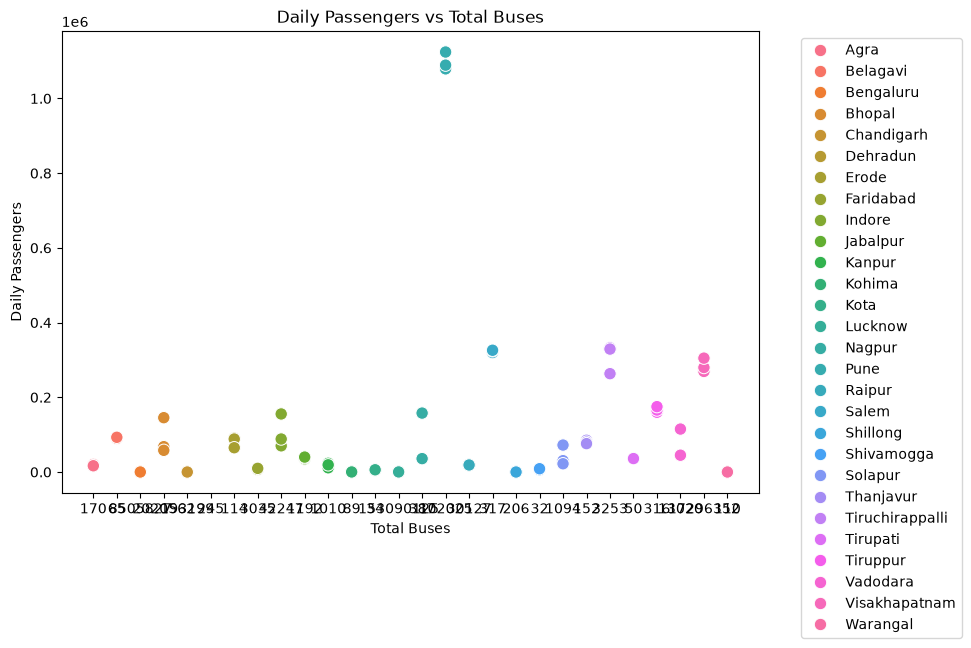

In [16]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=transport_df,
    x="total_buses",
    y="daily_passengers",
    hue="city",
    s=80
)

plt.title("Daily Passengers vs Total Buses")
plt.xlabel("Total Buses")
plt.ylabel("Daily Passengers")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

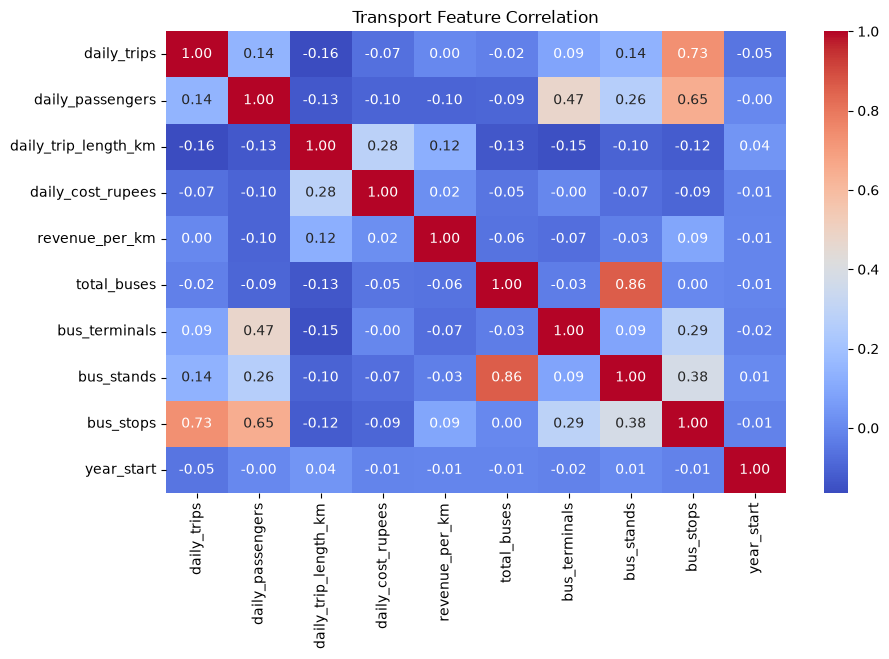

In [17]:
plt.figure(figsize=(10, 6))

correlation_columns = [
    "daily_trips",
    "daily_passengers",
    "daily_trip_length_km",
    "daily_cost_rupees",
    "revenue_per_km",
    "total_buses",
    "bus_terminals",
    "bus_stands",
    "bus_stops",
    "year_start"
]

sns.heatmap(
    transport_df[correlation_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Transport Feature Correlation")
plt.show()

In [22]:
features = [
    "city",
    "year_start",
    "daily_trips",
    "daily_trip_length_km",
    "total_buses",
    "bus_terminals",
    "bus_stands",
    "bus_stops"
]

target = "daily_passengers"

model_data = transport_df[features + [target]].dropna()
X = model_data[features].copy()
y = model_data[target].copy()

print("Features:", X.shape)
print("Target:", y.shape)

Features: (64, 8)
Target: (64,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

categorical_features = ["city"]

numeric_features = [
    column for column in features
    if column not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "city_encoder",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

transport_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=8,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

transport_model.fit(X_train, y_train)

predictions = transport_model.predict(X_test)

In [25]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Transport Model Performance")
print(f"MAE: {mae:.2f} passengers/day")
print(f"RMSE: {rmse:.2f} passengers/day")
print(f"R²: {r2:.4f}")

Transport Model Performance
MAE: 31835.39 passengers/day
RMSE: 47730.01 passengers/day
R²: 0.9729


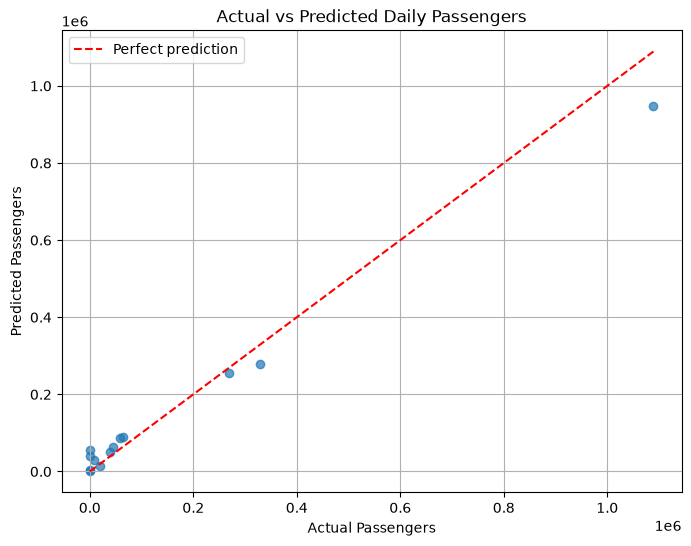

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, predictions, alpha=0.7)

minimum = min(y_test.min(), predictions.min())
maximum = max(y_test.max(), predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "r--",
    label="Perfect prediction"
)

plt.title("Actual vs Predicted Daily Passengers")
plt.xlabel("Actual Passengers")
plt.ylabel("Predicted Passengers")
plt.legend()
plt.grid()
plt.show()

In [27]:
def get_crowd_level(passengers):
    if passengers < 5000:
        return "LOW"
    elif passengers < 20000:
        return "MEDIUM"
    return "HIGH"


def get_transport_recommendation(crowd_level):
    if crowd_level == "LOW":
        return "Normal service frequency is sufficient."
    elif crowd_level == "MEDIUM":
        return "Monitor demand and consider additional trips during peak hours."
    return "High passenger demand expected. Add buses and increase service frequency."

In [28]:
import joblib
from pathlib import Path

transport_bundle = {
    "model": transport_model,
    "features": features,
    "metrics": {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2)
    }
}

joblib.dump(
    transport_bundle,
    Path("../models/transport_demand_model.joblib")
)

print("Transport model saved successfully.")
print(transport_bundle["metrics"])

Transport model saved successfully.
{'mae': 31835.389041606533, 'rmse': 47730.01386382361, 'r2': 0.972926475115754}
